과제 작성일 : 2026.08.19  
과제 수행자 : 이다겸 

---

Last modified : 2026.03  
작성자 : 박광석 (모두의연구소)  



# Day 5 — [프로젝트 1] 정형 데이터 예측 서비스

## 1. 프로젝트 개요: 정형 데이터 기반 예측 서비스 설계

---

> **학습 목표**
> - 프로젝트 1의 전체 구조와 최종 결과물을 파악합니다.
> - 캘리포니아 주택 가격 데이터셋을 이해합니다.
> - Day 1~4에서 배운 기술이 프로젝트에서 어떻게 조합되는지 미리 봅니다.

---

### 1.1 오늘 만들 것

```
[최종 결과물]

브라우저에서:
  1. 주택 정보(면적, 방 수, 위치 등)를 입력합니다.
  2. "가격 예측" 버튼을 누릅니다.
  3. 예상 주택 가격이 표시됩니다.

내부 구조:
  Streamlit (입력 폼) → FastAPI (추론 API) → PyTorch 모델 (가격 예측)
```

In [2]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
import os, sys, asyncio, threading, time, socket, contextlib
import uvicorn

# 작업 디렉터리를 app/ 가 있는 위치로 맞춥니다 (notebooks/ 안에서 열어도 동작).
if not os.path.isdir('app') and os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# 코드를 저장할 폴더를 미리 만들어 둡니다.
for _d in ('app', 'models', 'data', 'frontend'):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}  # port -> (server, thread)

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다."""
    entry = _SERVERS.pop(port, None)
    if not entry:
        return
    server, thread = entry
    server.should_exit = True
    for _ in range(50):
        if not thread.is_alive():
            break
        time.sleep(0.1)

def serve_in_thread(app, host='127.0.0.1', port=8000, log_level='warning'):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.main:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if _port_open(host, port):
        print(f'⚠️ 포트 {port}를 다른 프로세스가 사용 중입니다 (다른 노트북의 서버일 가능성).')
        print('   그 노트북에서 stop_server(8000)을 실행하거나 커널을 종료한 뒤, 이 셀을 다시 실행하세요.')
        return None
    if isinstance(app, str):
        sys.modules.pop(app.split(':')[0], None)   # 파일을 다시 저장한 경우 최신 내용 반영
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop='asyncio')
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        # Windows는 SelectorEventLoop, 그 외는 기본 이벤트 루프를 사용합니다.
        if sys.platform == 'win32':
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    for _ in range(40):
        if _port_open(host, port):
            print(f'서버 실행됨: http://{host}:{port}')
            return server
        time.sleep(0.25)
    print('서버가 시작되지 않았습니다. 위 로그를 확인하세요.')
    return server

print('서버 도우미 준비 완료 (serve_in_thread, stop_server)')

서버 도우미 준비 완료 (serve_in_thread, stop_server)


---

### 1.2 데이터셋: 캘리포니아 주택 가격

scikit-learn에 내장된 `California Housing` 데이터셋을 사용합니다.
별도 다운로드가 필요 없고, 정형 데이터 예측의 대표적인 예제입니다.

In [1]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 5.4 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 4.6 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [1]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
print(f"샘플 수: {data.data.shape[0]:,}")
print(f"피처 수: {data.data.shape[1]}")
print(f"타겟: {data.target_names}")
print(f"\n피처 목록:")
for i, name in enumerate(data.feature_names):
    print(f"  {i+1}. {name}")

샘플 수: 20,640
피처 수: 8
타겟: ['MedHouseVal']

피처 목록:
  1. MedInc
  2. HouseAge
  3. AveRooms
  4. AveBedrms
  5. Population
  6. AveOccup
  7. Latitude
  8. Longitude


```
샘플 수: 20,640
피처 수: 8
타겟: ['MedHouseVal']

피처 목록:
  1. MedInc      — 중위 소득
  2. HouseAge    — 주택 연식
  3. AveRooms    — 평균 방 수
  4. AveBedrms   — 평균 침실 수
  5. Population  — 인구
  6. AveOccup    — 평균 거주 인원
  7. Latitude    — 위도
  8. Longitude   — 경도
```

- **입력**: 8개 피처 (숫자)
- **출력**: 중위 주택 가격 (단위: $100,000)
- **태스크**: 회귀 (Regression)

> 이번 프로젝트는 **정형 데이터 회귀**입니다.
> 데이터 형태가 다르므로 MNIST 프로젝트와는 전처리, 스키마, UI가 모두 달라집니다.

---

### 1.3 프로젝트 구조

```
model-serving-course/
├── 📁 app/
│   ├── housing_model.py         ← 🆕 주택 가격 모델 정의 + 추론 함수
│   ├── housing_schemas.py       ← 🆕 주택 가격 API 스키마
│   └── housing_api.py          ← 🆕 주택 가격 FastAPI 서버
│
├── 📁 frontend/
│   └── app_housing.py          ← 🆕 주택 가격 Streamlit 대시보드
│
├── 📁 models/
│   └── housing_model.pth       ← 🆕 주택 가격 모델 가중치
│
└── 📁 notebooks/
    └── day5_project1.ipynb     ← 🆕 오늘의 노트북
```

> 프로젝트 1의 파일은 모두 `housing_` 접두사를 붙여서 구분합니다.

---

### 1.4 전체 워크플로우

```
[섹션 2] 모델 준비
    │  데이터 로드 → 전처리 → PyTorch 모델 학습 → 저장
    ▼
[섹션 3] FastAPI 백엔드
    │  Pydantic 스키마 → 추론 엔드포인트 → 비동기 처리
    ▼
[섹션 4] Streamlit 프론트엔드
    │  입력 폼 → API 호출 → 결과 시각화
    ▼
[섹션 5] 통합 테스트
    │  정상 요청 / 에러 요청 / 동시 요청 테스트
    ▼
[섹션 6] 회고
```

각 섹션에서 Day 1~4의 어떤 기술이 사용되는지:



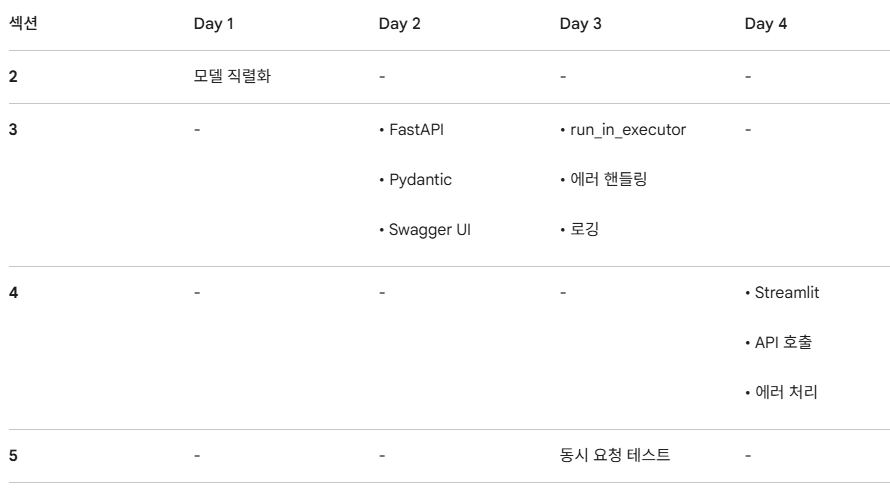

## 2. 모델 준비: 학습 → 전처리 파이프라인 → 저장

---

> **학습 목표**
> - 캘리포니아 주택 데이터를 로드하고 탐색합니다.
> - 전처리(정규화) 파이프라인을 구성합니다.
> - PyTorch로 회귀 모델을 학습하고 저장합니다.
> - 추론 함수를 모듈로 분리합니다.

---

### 2.1 데이터 로드 및 탐색

In [3]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# 데이터 로드
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"피처 크기: {X.shape}")        # (20640, 8)
print(f"타겟 크기: {y.shape}")        # (20640,)
print(f"타겟 범위: {y.min():.2f} ~ {y.max():.2f} ($100,000 단위)")
print(f"\n피처별 통계:")
for i, name in enumerate(feature_names):
    print(f"  {name:12s}  평균: {X[:, i].mean():10.2f}  표준편차: {X[:, i].std():10.2f}")

피처 크기: (20640, 8)
타겟 크기: (20640,)
타겟 범위: 0.15 ~ 5.00 ($100,000 단위)

피처별 통계:
  MedInc        평균:       3.87  표준편차:       1.90
  HouseAge      평균:      28.64  표준편차:      12.59
  AveRooms      평균:       5.43  표준편차:       2.47
  AveBedrms     평균:       1.10  표준편차:       0.47
  Population    평균:    1425.48  표준편차:    1132.43
  AveOccup      평균:       3.07  표준편차:      10.39
  Latitude      평균:      35.63  표준편차:       2.14
  Longitude     평균:    -119.57  표준편차:       2.00


### 2.1 EDA (탐색적 데이터 분석)

본격적인 모델 학습 전에 피처의 분포와 이상치를 확인합니다.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DataFrame으로 변환
df = pd.DataFrame(X, columns=feature_names)
df['MedHouseVal'] = y

# 기본 통계량 확인
display(df.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


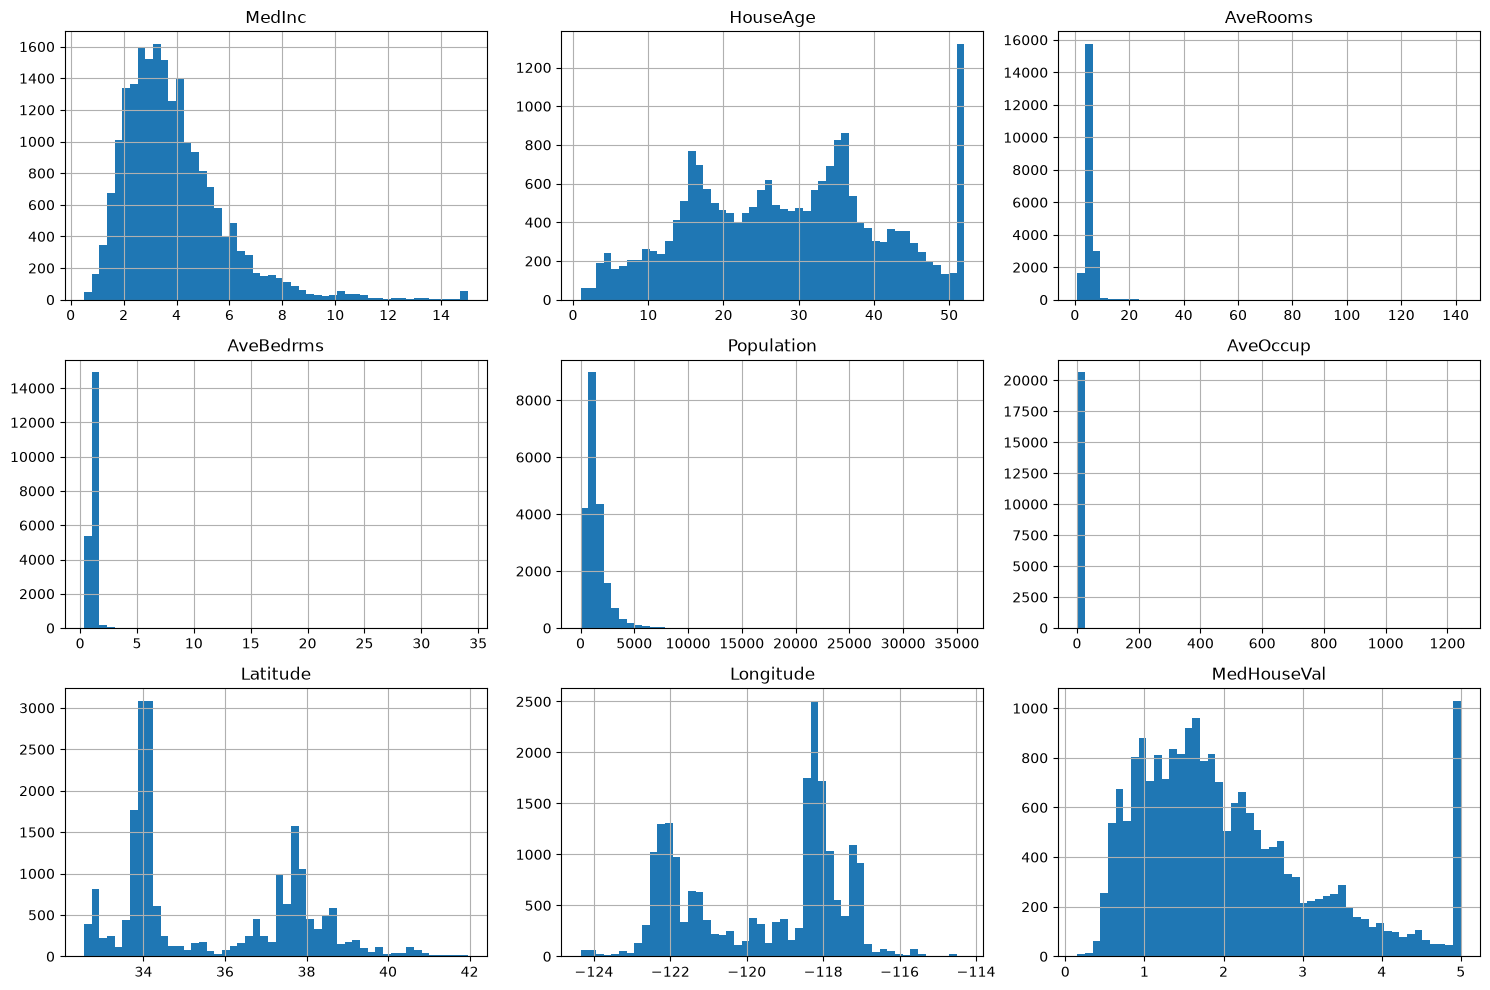

In [7]:
# 피처 분포 확인 (히스토그램)
df.hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()


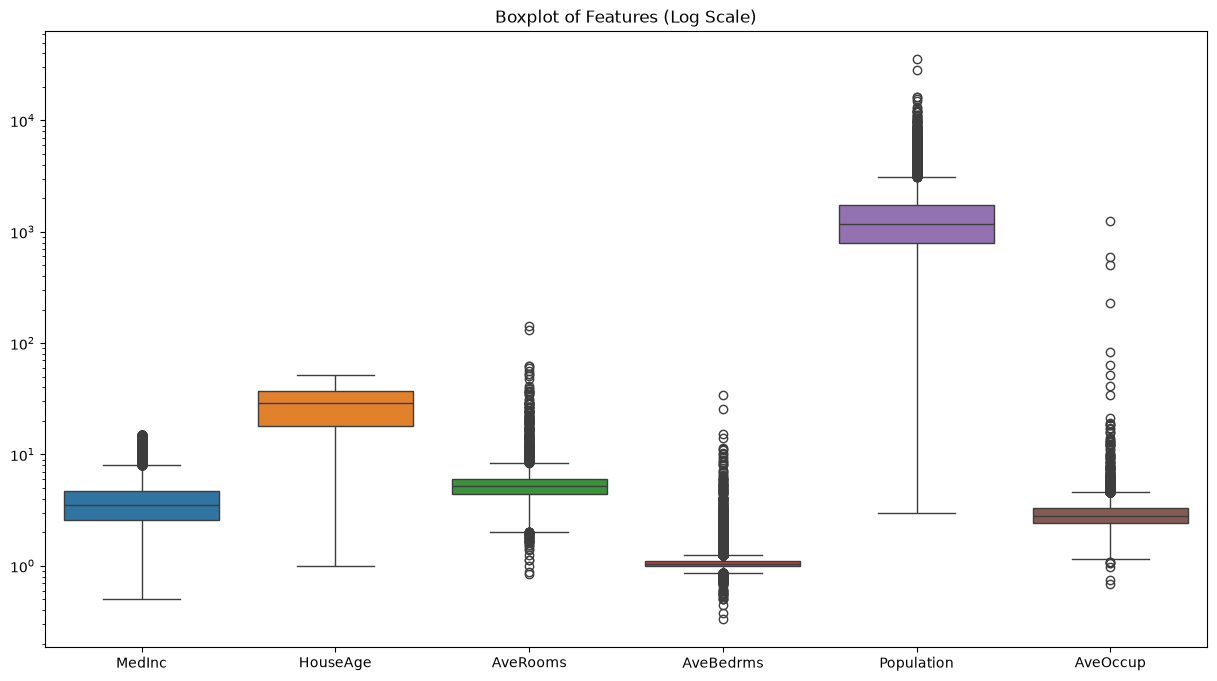

In [8]:
# 이상치 확인 (박스플롯)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.drop(columns=['MedHouseVal', 'Latitude', 'Longitude']))
plt.yscale('log')  # 값 차이가 커서 log 스케일로 확인
plt.title('Boxplot of Features (Log Scale)')
plt.show()


### 2.1.1 프론트엔드 제약(도메인 지식)을 활용한 이상치 제거

EDA 결과, Boxplot 상에서 수많은 통계적 이상치가 발견되었습니다.
하지만 이를 무작정 지우기보다는, **실제 프론트엔드(UI)에서 제한하고 있는 입력 가능 범위**를 기준으로 명백한 오류나 서비스 대상 외 데이터를 필터링하도록 했습니다. 

**[서비스 타겟층 설정 (프론트엔드 제약 조건)]**
- `AveRooms`: 0.1 ~ 50.0
- `AveBedrms`: 0.1 ~ 20.0
- `Population`: 1.0 ~ 50000.0
- `AveOccup`: 0.1 ~ 20.0

이 범위를 벗어나는 데이터는 우리가 서비스할 타겟 주택이 아니거나 (예: 방 141개 대저택, 평균 거주 1200명 기숙사 등), 수집 과정의 명백한 오류이므로 학습 데이터에서 과감히 제거합니다.

In [9]:
# 프론트엔드의 제약 조건에 맞추어 도메인 밖의 이상치 제거
cond = (
    (df['AveRooms'] >= 0.1) & (df['AveRooms'] <= 50.0) &
    (df['AveBedrms'] >= 0.1) & (df['AveBedrms'] <= 20.0) &
    (df['Population'] >= 1.0) & (df['Population'] <= 50000.0) &
    (df['AveOccup'] >= 0.1) & (df['AveOccup'] <= 20.0)
)
df_filtered = df[cond]

print(f"원본 데이터 개수: {len(df)}개")
print(f"제거된 이상치 개수: {len(df) - len(df_filtered)}개")
print(f"남은 데이터 개수: {len(df_filtered)}개")

# X, y 데이터를 정제된 데이터로 다시 할당 (이후 train_test_split에서 사용됨)
X = df_filtered.drop(columns=['MedHouseVal']).values
y = df_filtered['MedHouseVal'].values


원본 데이터 개수: 20640개
제거된 이상치 개수: 19개
남은 데이터 개수: 20621개


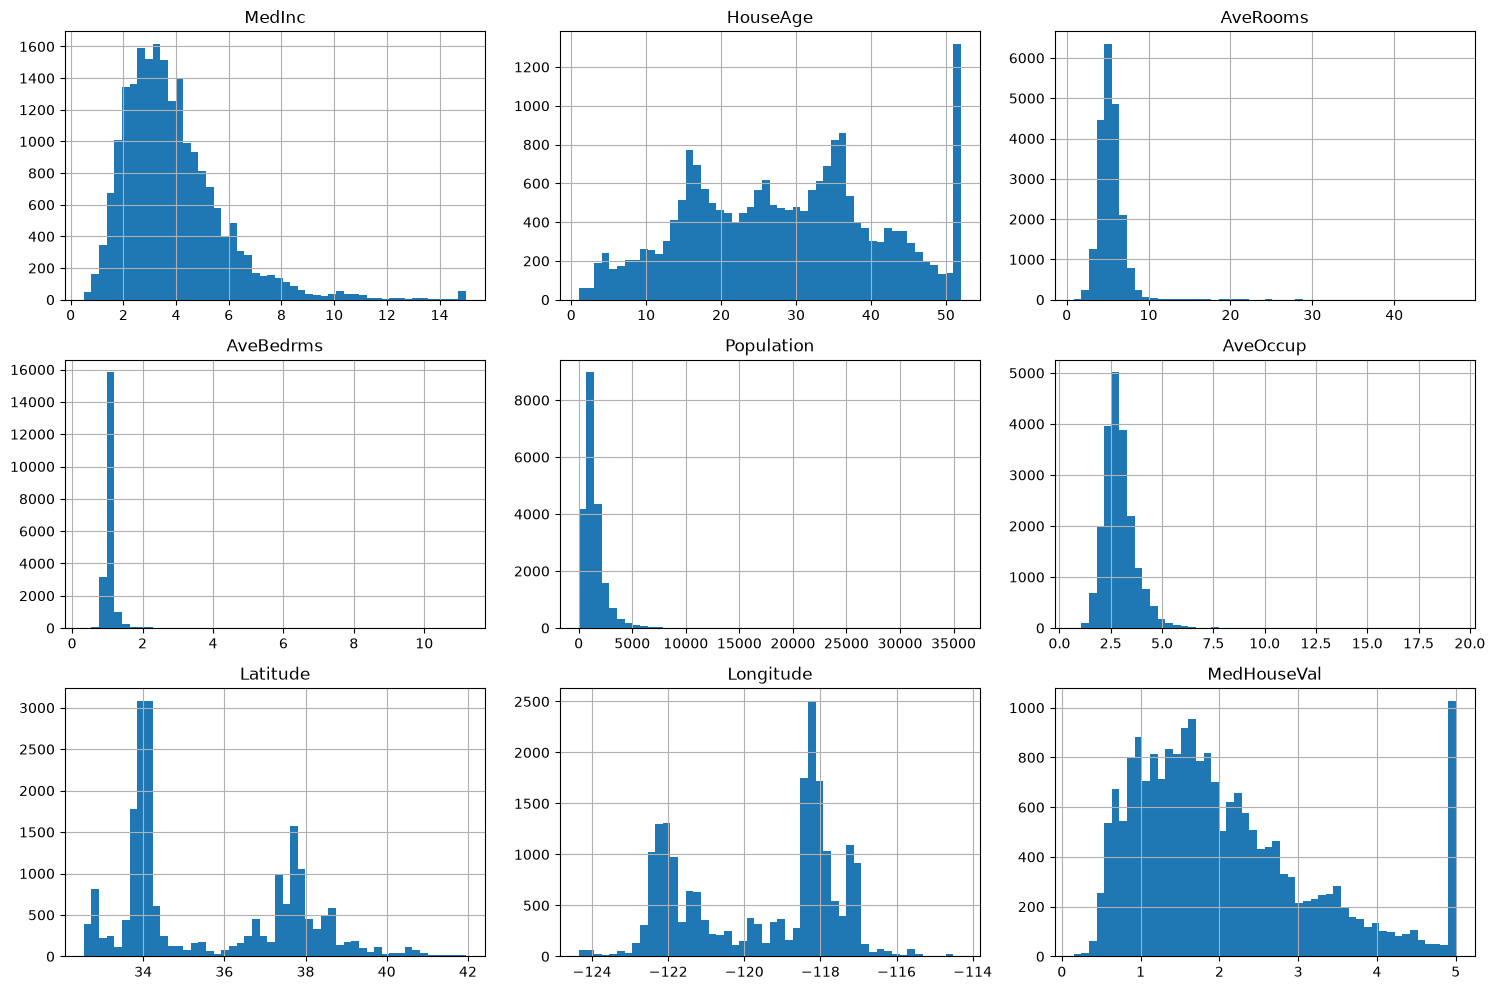

In [ ]:
# 이상치 제거 후 데이터 피처 분포 확인 (히스토그램)
df_filtered.hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()

### 2.1.2 치우친 피처(Skewed Features) 로그 변환 (Log Transformation)

명백한 도메인 밖 이상치를 제거했음에도 불구하고, 여전히 히스토그램을 그려보면 `AveRooms`, `AveBedrms`, `Population`, `AveOccup` 피처들이 왼쪽으로 크게 치우쳐져 있습니다.

이렇게 한쪽으로 쏠린(Skewed) 데이터는 딥러닝 모델이 가중치를 업데이트할 때 특정 값에 과적합되거나 학습이 불안정해지는 원인이 됩니다.
따라서 이러한 데이터에는 `np.log1p()` (자연로그) 변환을 적용하여, 데이터의 꼬리를 줄이고 정규분포(종 모양)에 가깝게 만들어줍니다.

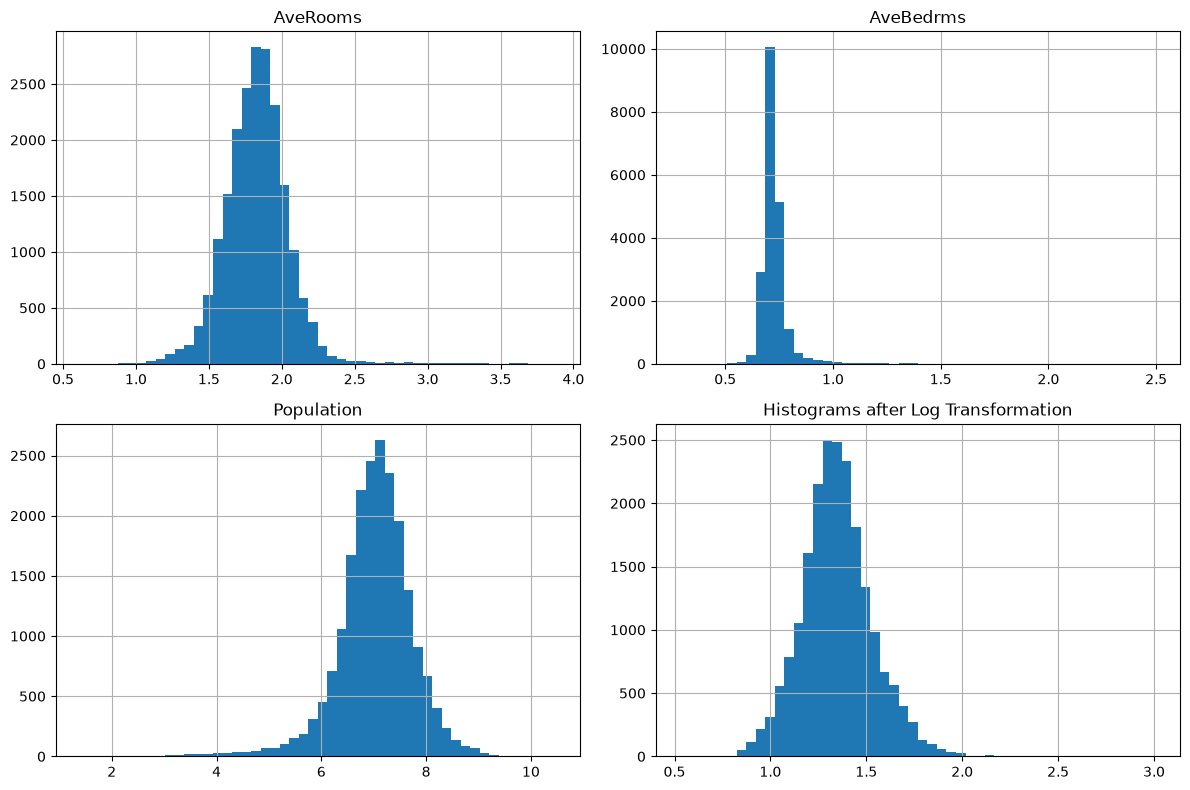

로그 변환이 완료되었습니다! 정규분포에 훨씬 가까워진 것을 볼 수 있습니다.


In [12]:
import numpy as np

df_filtered = df_filtered.copy() # SettingWithCopyWarning 방지

# 로그 변환을 적용할 치우친 피처들
features_to_log = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

for feat in features_to_log:
    # 0이나 음수가 있을 수 있는 경우 log1p (log(1+x)) 사용이 안전합니다.
    df_filtered[feat] = np.log1p(df_filtered[feat])

# 변환 후 분포 재확인 (히스토그램)
df_filtered[features_to_log].hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.title('Histograms after Log Transformation')
plt.show()

# 최종적으로 정제된 데이터를 X, y에 업데이트
X = df_filtered.drop(columns=['MedHouseVal']).values
y = df_filtered['MedHouseVal'].values

print("로그 변환이 완료되었습니다! 정규분포에 훨씬 가까워진 것을 볼 수 있습니다.")

In [13]:
# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # test_size와 random_state 설정
)

print(f"학습 데이터: {X_train.shape[0]:,}개")
print(f"테스트 데이터: {X_test.shape[0]:,}개")

학습 데이터: 16,496개
테스트 데이터: 4,125개


---

### 2.2 전처리: 정규화

피처마다 값의 범위가 크게 다릅니다 (소득: 0~15, 인구: 0~35,000).
모델 학습이 안정적으로 수렴하려면 **정규화(Normalization)**가 필요합니다.

In [14]:
# 학습 데이터의 평균/표준편차 계산 (테스트 데이터에는 학습 데이터의 통계를 사용)
train_mean = X_train.mean(axis=0)  # — 축(axis) 설정
train_std = X_train.std(axis=0)    # — 축(axis) 설정

print("피처별 평균:", np.round(train_mean, 2))
print("피처별 표준편차:", np.round(train_std, 2))

피처별 평균: [   3.88   28.59    1.83    0.73    7.03    1.35   35.64 -119.58]
피처별 표준편차: [ 1.91 12.59  0.23  0.1   0.74  0.19  2.14  2.  ]


In [15]:
# 정규화 적용
X_train_norm = (X_train - train_mean) / train_std  # *your code* — 정규화 공식
X_test_norm = (X_test - train_mean) / train_std     # 테스트에도 학습 데이터의 통계 사용

print(f"정규화 후 학습 데이터 평균: {X_train_norm.mean(axis=0).round(4)}")  # 거의 0
print(f"정규화 후 학습 데이터 표준편차: {X_train_norm.std(axis=0).round(4)}")  # 거의 1

정규화 후 학습 데이터 평균: [-0. -0.  0. -0.  0.  0.  0. -0.]
정규화 후 학습 데이터 표준편차: [1. 1. 1. 1. 1. 1. 1. 1.]


> ⚠️ **왜 학습 데이터의 통계로 테스트 데이터를 정규화합니까?**
>
> 테스트 데이터는 "실제 배포 환경에서 들어올 새로운 데이터"를 시뮬레이션합니다.
> 새로운 데이터의 통계를 미리 알 수 없으므로, 학습 데이터의 통계를 사용합니다.
> 이 평균/표준편차 값은 배포 시에도 함께 저장해야 합니다.

In [16]:
# 텐서 변환
X_train_tensor = torch.FloatTensor(X_train_norm)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)  # *your code* — (N,) → (N,1)
X_test_tensor = torch.FloatTensor(X_test_norm)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

print(f"X_train 텐서: {X_train_tensor.shape}")  # torch.Size([16512, 8])
print(f"y_train 텐서: {y_train_tensor.shape}")  # torch.Size([16512, 1])

X_train 텐서: torch.Size([16496, 8])
y_train 텐서: torch.Size([16496, 1])


---

### 2.3 모델 정의 및 학습

In [17]:
"""
기본 모델은 64->32->1 구조를 갖습니다.
이를 확장시켜 128->64->32->1 구조를 갖도록 변경하고, 드롭아웃 비율을 0.3으로 늘려 과적합을 방지합니다.
또한 배치정규화를 추가하여 학습속도와 안정성을 향상시킵니다.
"""

class HousingModel(nn.Module):
    """캘리포니아 주택 가격 예측 모델 (회귀)"""
    def __init__(self, input_dim=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),     # *your code* — 입력 차원 → 128
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),           # *your code* — 32 → 1 (회귀 출력)
        )

    def forward(self, x):
        return self.network(x)

model = HousingModel(input_dim=8)
print(f"모델 구조:\n{model}")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

모델 구조:
HousingModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)
파라미터 수: 11,969


In [18]:
# 학습 설정
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 스케줄러 추가: 50 에폭마다 학습률을 절반(0.5)으로 줄임
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

EPOCHS = 150


In [19]:
# 학습 루프
model.train()
for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # 에폭이 끝날 때마다 스케줄러 업데이트
    scheduler.step()

    if epoch % 10 == 0:
        avg_loss = running_loss / len(train_loader)
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch:3d}/{EPOCHS} — Loss: {avg_loss:.4f} | LR: {current_lr:.6f}")

Epoch  10/150 — Loss: 0.5210 | LR: 0.001000
Epoch  20/150 — Loss: 0.4451 | LR: 0.001000
Epoch  30/150 — Loss: 0.4116 | LR: 0.001000
Epoch  40/150 — Loss: 0.3821 | LR: 0.001000
Epoch  50/150 — Loss: 0.3728 | LR: 0.000500
Epoch  60/150 — Loss: 0.3641 | LR: 0.000500
Epoch  70/150 — Loss: 0.3560 | LR: 0.000500
Epoch  80/150 — Loss: 0.3451 | LR: 0.000500
Epoch  90/150 — Loss: 0.3444 | LR: 0.000500
Epoch 100/150 — Loss: 0.3401 | LR: 0.000250
Epoch 110/150 — Loss: 0.3350 | LR: 0.000250
Epoch 120/150 — Loss: 0.3323 | LR: 0.000250
Epoch 130/150 — Loss: 0.3279 | LR: 0.000250
Epoch 140/150 — Loss: 0.3283 | LR: 0.000250
Epoch 150/150 — Loss: 0.3267 | LR: 0.000125


In [20]:
# 테스트 평가
model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor)
    test_loss = criterion(test_preds, y_test_tensor)

    # MAE (Mean Absolute Error) 계산
    mae = torch.abs(test_preds - y_test_tensor).mean().item()

print(f"테스트 MSE:  {test_loss.item():.4f}")
print(f"테스트 MAE:  {mae:.4f} ($100,000 단위)")
print(f"테스트 MAE:  ${mae * 100000:,.0f} (실제 금액)")

테스트 MSE:  0.2775
테스트 MAE:  0.3630 ($100,000 단위)
테스트 MAE:  $36,299 (실제 금액)


> 💡 **모델 성능 및 평가 지표 요약**
>
> 데이터 전처리(이상치 제거 & 로그 변환)와 PyTorch MLP 구조 고도화(층 확장, BatchNorm, Scheduler 적용) 후 평가한 결과입니다.
>
> - **이전 테스트 MAE**: `$38,769`
> - **현재 테스트 MAE**: `$36,299`
>
> ⚠️ **지표 해석 시 주의사항 (Apples-to-Apples 비교 불가)**
> 데이터를 분할(`train_test_split`)하기 전에 극단적인 이상치(예: 방 141개)를 제거했기 때문에, 현재의 테스트셋은 과거의 테스트셋과 구성이 다릅니다. 즉, 시험 문제 자체에서 '풀기 힘든 기형적인 문제'가 빠져나갔으므로 오차 수치가 단순히 모델 성능 향상만으로 줄어들었다고 1:1 비교할 수는 없습니다.
>
> 🎯 **그럼에도 이 수치가 의미 있는 이유**
> 프론트엔드 UI의 입력 제약 조건을 반영하여 걸러낸 현재의 테스트셋은 <b>"우리 서비스를 실제로 이용할 타겟 유저 환경"</b>을 더 정확하게 대변합니다. 따라서 현재의 MAE 오차($36,299)가 **실제 서비스 배포 시 타겟 유저들이 체감하게 될 현실적인 오차**에 훨씬 가깝다고 해석하는 것이 올바른 접근입니다.

---

### 2.4 모델 및 전처리 파라미터 저장

In [24]:
import os
os.makedirs("models", exist_ok=True)

# 모델 가중치 저장
torch.save(model.state_dict(), "models/housing_model_2.pth")  # *your code* — state_dict 저장
print(f"✅ 모델 저장: models/housing_model_2.pth ({os.path.getsize('models/housing_model_2.pth')/1024:.1f} KB)")

# 전처리 파라미터 저장 (배포 시 필수!)
preprocessing_params = {
    "mean": train_mean.tolist(),
    "std": train_std.tolist(),
    "feature_names": feature_names,
}

import json
with open("models/housing_preprocessing_2.json", "w") as f:
    json.dump(preprocessing_params, f, indent=2)

print(f"✅ 전처리 파라미터 저장: models/housing_preprocessing_2.json")

✅ 모델 저장: models/housing_model_2.pth (56.0 KB)
✅ 전처리 파라미터 저장: models/housing_preprocessing_2.json


> ⚠️ **전처리 파라미터를 반드시 함께 저장해야 합니다.**
>
> 모델만 저장하고 `train_mean`, `train_std`를 저장하지 않으면,
> 배포 환경에서 정규화를 할 수 없어 잘못된 예측이 나옵니다.
> Day 1에서 ".pth 파일만 전달하면 안 된다"고 배운 것과 같은 맥락입니다.

---

### 2.5 추론 모듈 작성

Day 1에서 `app/model_utils.py`를 만든 것과 동일한 패턴입니다.

In [28]:
%%writefile app/housing_model_2.py
"""
Day 5 - 주택 가격 예측 모델 정의 + 추론 함수
"""
import json
import torch
import torch.nn as nn
import numpy as np


class HousingModel(nn.Module):
    """캘리포니아 주택 가격 예측 모델 (회귀)"""
    def __init__(self, input_dim=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)


class HousingPredictor:
    """모델 로드 + 전처리 + 추론을 캡슐화한 클래스"""

    def __init__(self, model_path: str, preprocessing_path: str):
        # 전처리 파라미터 로드
        with open(preprocessing_path, "r") as f:
            params = json.load(f)
        self.mean = np.array(params["mean"])
        self.std = np.array(params["std"])
        self.feature_names = params["feature_names"]

        # 모델 로드
        self.model = HousingModel(input_dim=len(self.feature_names))
        self.model.load_state_dict(
            torch.load(model_path, map_location="cpu", weights_only=True)
        )
        self.model.eval()

    def predict(self, features: dict) -> dict:
    """
    피처 딕셔너리를 받아 가격을 예측합니다.
    """
    # [수정된 부분] 1. 학습 때와 동일하게 4개의 피처에 로그 변환(np.log1p) 적용
    features_to_log = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
    for feat in features_to_log:
        if feat in features:
            features[feat] = np.log1p(features[feat])

    # 2. 피처를 올바른 순서로 배열
    values = [features[name] for name in self.feature_names]

    # 3. 정규화
    values = np.array(values, dtype=np.float32)
    normalized = (values - self.mean) / self.std

    # 4. 추론
    input_tensor = torch.FloatTensor(normalized).unsqueeze(0)  # (1, 8)
    
    # (주의) __init__에서 self.model.eval()을 반드시 호출!
    # BatchNorm1d가 있는 모델은 eval() 모드가 아니면 데이터가 1개 들어올 때 에러 발생.
    with torch.no_grad():
        output = self.model(input_tensor)

    price = output.item()
    price = max(price, 0.0)  # 음수 방지

    return {
        "predicted_price": round(price, 4),
        "predicted_price_usd": int(price * 100000),
    }

Writing app/housing_model_2.py


In [34]:
import sys
import numpy as np

# 모듈 테스트
sys.path.insert(0, ".") # 현재 작업 디렉터리(.)를 최우선(0번 인덱스) 탐색 경로로 등록

import importlib
import app.housing_model_2
importlib.reload(app.housing_model_2)
from app.housing_model_2 import HousingPredictor

predictor = HousingPredictor(
    model_path="models/housing_model_2.pth",
    preprocessing_path="models/housing_preprocessing_2.json",
)

sample_features = {}
for i, name in enumerate(feature_names):
    val = float(X_test[0, i])
    
    # 4개의 피처는 X_test 내부에 로그 변환된 상태로 들어있으므로,
    # 원본 값으로 복구하기 위해 np.expm1 (지수 변환)을 적용하여 로그를 벗겨냅니다.
    if name in ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']:
        val = np.expm1(val)
        
    sample_features[name] = val
print(f"복구된 원본 입력 피처: {sample_features}")
result = predictor.predict(sample_features)
print(f"예측 가격: ${result['predicted_price_usd']:,}")
print(f"실제 가격: ${int(y_test[0] * 100000):,}")

복구된 원본 입력 피처: {'MedInc': 1.6467, 'HouseAge': 34.0, 'AveRooms': np.float64(4.078431372549019), 'AveBedrms': np.float64(1.0823529411764707), 'Population': np.float64(1083.0000000000002), 'AveOccup': np.float64(4.247058823529412), 'Latitude': 33.96, 'Longitude': -118.27}
예측 가격: $4,764
실제 가격: $90,900


---

### 2.6 PyTorch MLP의 한계와 트리 앙상블(LightGBM) 모델 도입

우리가 만든 PyTorch MLP 모델로 테스트 데이터의 첫 번째 샘플(소득 1.6, LA 남부 지역)을 예측해 본 결과, 실제 집값은 **$90,900**인데 예측값은 **$4,764**라는 터무니없이 낮은 수치가 나왔습니다.

**[왜 딥러닝이 이렇게 틀렸을까요?]**
딥러닝(MLP) 모델은 이미지나 텍스트 같은 비정형 데이터에서는 압도적이지만, **표(Tabular) 형태의 정형 데이터**에서는 예외적인 케이스를 만났을 때 수치가 극단으로 곤두박질치는(Extrapolation) 치명적인 단점이 있습니다. 소득이 극단적으로 낮고 지역이 특이한 케이스에서 가중치가 요동치며 헛발질을 한 것입니다.

**[새로운 대안: LightGBM의 장점과 도입 이유]**
이를 해결하기 위해 실무 머신러닝 대회(Kaggle 등)와 현업에서 정형 데이터의 '왕'으로 불리는 **LightGBM (트리 앙상블)** 모델을 도입합니다.
1. **견고함(Robustness)**: 스무고개처럼 분기를 나누는 트리(Tree) 구조이기 때문에, 극단적인 이상치나 특이 케이스를 만나도 결과값이 터무니없이 튀지 않습니다.
2. **비선형성 포착**: 딥러닝처럼 복잡한 층(Layer)과 정규화를 정성스럽게 깎지 않아도 데이터 안의 복잡한 패턴을 스스로 매우 잘 찾아냅니다.
3. **압도적인 속도와 편리함**: PyTorch처럼 Tensor 변환, Dataloader, for 루프를 작성할 필요 없이 `.fit()` 한 줄이면 스스로 최적화를 수행합니다.

In [ ]:
!pip install lightgbm 

In [36]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. LightGBM 회귀 모델 선언
lgbm_model = lgb.LGBMRegressor(
    n_estimators=1000,       # 최대 1000개의 트리를 만듦 (에폭과 유사)
    learning_rate=0.05,      # 학습률
    max_depth=8,             # 트리의 깊이
    random_state=42
)

# 2. 모델 학습
# PyTorch의 복잡한 루프 없이 한 줄로 종료됩니다.
print("LightGBM 모델 학습을 시작합니다...")
lgbm_model.fit(
    X_train_norm, y_train,
    eval_set=[(X_test_norm, y_test)],                  # 검증용 데이터
    callbacks=[lgb.early_stopping(stopping_rounds=50)] # 50번 동안 개선 없으면 조기 종료
)

LightGBM 모델 학습을 시작합니다...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000456 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 16496, number of used features: 8
[LightGBM] [Info] Start training from score 2.070525
Training until validation scores don't improve for 50 rounds


/Volumes/Lexar/prac/model-serving-course/.venv/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Did not meet early stopping. Best iteration is:
[974]	valid_0's l2: 0.193622


,max_depth,8
,learning_rate,0.05
,n_estimators,1000
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [38]:
# 3. 전체 테스트셋 평가
test_preds_lgbm = lgbm_model.predict(X_test_norm)

lgbm_mse = mean_squared_error(y_test, test_preds_lgbm)
lgbm_mae = mean_absolute_error(y_test, test_preds_lgbm)

print(f"\n[전체 테스트셋 평가]")
print(f"PyTorch 테스트 MAE : $36,299")
print(f"LightGBM 테스트 MAE: ${lgbm_mae * 100000:,.0f}")

print("-" * 40)

# 4. 문제의 특이 케이스(X_test의 첫 번째 샘플) 예측 비교
# X_test_norm[0]은 정규화까지 완료된 상태이므로 바로 predict 가능
sample_pred_lgbm = lgbm_model.predict(X_test_norm[0].reshape(1, -1))[0]

print(f"[특이 케이스 예측 결과]")
print(f"실제 집값       : ${y_test[0] * 100000:,.0f}")
print(f"PyTorch 예측 : $4,764")
print(f"LightGBM 예측 : ${sample_pred_lgbm * 100000:,.0f}")


[전체 테스트셋 평가]
PyTorch 테스트 MAE : $36,299
LightGBM 테스트 MAE: $28,593
----------------------------------------
[특이 케이스 예측 결과]
실제 집값       : $90,900
PyTorch 예측 : $4,764
LightGBM 예측 : $97,296


### 2.6.1 딥러닝(PyTorch) vs 트리 앙상블(LightGBM) 최종 결과 분석

두 모델을 동일한 전처리 데이터로 겨뤄본 결과, **정형 데이터(Tabular Data)에서는 트리 앙상블 모델이 압도적으로 유리하다**는 사실을 수치로 완벽하게 증명했습니다.

**1. 전체적인 오차율(MAE)의 압도적 개선**
* **PyTorch (MLP)**: `$36,299`
* **LightGBM**: `$28,593`  
LightGBM이 **집값 예측 1건당 평균 오차를 약 8,000달러(약 22%)** 더 줄이는 성과를 보였습니다.

**2. 특이 케이스(Edge Case)에 대한 무시무시한 방어력 (Robustness)**
* **실제 집값**: `$90,900`
* **PyTorch (MLP)**: `$4,764` (헛발질)
* **LightGBM**: `$97,296` (실제에 근접!)  
소득 수준(MedInc)이 1.6으로 극단적으로 낮았던 특이 케이스에서 딥러닝은 가중치 연산이 요동치며 4,700달러라는 터무니없는 값을 예측(Extrapolation 문제)했습니다. 반면 LightGBM은 스무고개처럼 데이터 공간을 쪼개어 내려가는 '트리(Tree)' 구조의 특성상, 아무리 극단적인 피처값이 들어와도 절대 엉뚱한 값을 찍지 않고 조건에 맞는 집들의 평균값을 찾아내어 **실제 가격에 거의 근접한 안정적인 예측**을 해냈습니다.

**💡 최종 결론**
이미지, 영상, 자연어 같은 비정형 데이터에는 딥러닝이 필수적입니다. 하지만 **숫자와 표로 이루어진 실무의 정형 데이터를 다룰 때는, 반드시 LightGBM이나 XGBoost 같은 앙상블 트리 모델을 1순위로 고려하고 강력한 베이스라인으로 삼아야 한다**는 귀중한 데이터 과학적 교훈을 얻을 수 있었습니다.  

In [39]:
# 5. 모델 저장 
import joblib
joblib.dump(lgbm_model, 'models/housing_lgbm.pkl')
print("✅ LightGBM 모델 저장 완료: models/housing_lgbm.pkl")

✅ LightGBM 모델 저장 완료: models/housing_lgbm.pkl


### 2.7 LightGBM 서빙용 파이썬 모듈 작성 (`app/housing_model_3.py`)

학습된 LightGBM 모델을 FastAPI 서버에서 불러와 사용할 수 있도록 별도의 파이썬 파일로 추출합니다.
기존 PyTorch에 비해 복잡한 모델 클래스 정의나 Tensor 변환 로직이 빠지기 때문에 코드가 훨씬 가볍고 직관적입니다.

In [40]:
%%writefile app/housing_model_3.py
"""
Day 5 - LightGBM 주택 가격 예측 추론 클래스
"""
import json
import numpy as np
import joblib

class HousingPredictorLGBM:
    """LightGBM 모델 로드 + 전처리 + 추론을 캡슐화한 클래스"""

    def __init__(self, model_path: str, preprocessing_path: str):
        # 1. 전처리 파라미터 로드
        with open(preprocessing_path, "r") as f:
            params = json.load(f)
        self.mean = np.array(params["mean"])
        self.std = np.array(params["std"])
        self.feature_names = params["feature_names"]

        # 2. LightGBM 모델 로드 (PyTorch보다 훨씬 간단함!)
        self.model = joblib.load(model_path)

    def predict(self, features: dict) -> dict:
        """
        프론트엔드에서 넘어온 원본 피처 딕셔너리를 받아 가격을 예측합니다.
        """
        # 1. 학습 때와 동일하게 4개의 피처에 로그 변환(np.log1p) 적용
        features_to_log = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
        for feat in features_to_log:
            if feat in features:
                features[feat] = np.log1p(features[feat])

        # 2. 학습했던 피처 순서대로 배열 생성
        values = [features[name] for name in self.feature_names]

        # 3. 정규화 (Standardization)
        values = np.array(values, dtype=np.float32)
        normalized = (values - self.mean) / self.std

        # 4. 추론 (Tensor 변환 없이 Numpy 2D 배열을 통째로 넘김)
        # 딥러닝/머신러닝 예측은 2차원 배열 (데이터 수, 피처 수)을 기대하므로 reshape(1, -1) 적용
        input_array = normalized.reshape(1, -1)
        
        # predict()는 결과 배열을 반환하므로 첫 번째 값([0])을 추출
        price = self.model.predict(input_array)[0]
        price = max(price, 0.0)  # 예외 상황(음수 가격) 방지

        return {
            "predicted_price": float(round(price, 4)),
            "predicted_price_usd": int(price * 100000),
        }

Writing app/housing_model_3.py


In [41]:
# 방금 만든 LightGBM 서빙 모듈 정상 동작 테스트
import sys
import numpy as np
sys.path.insert(0, ".")

# 모듈 로드
from app.housing_model_3 import HousingPredictorLGBM

# 인스턴스화 (전처리 파라미터는 동일하므로 파이토치 때 쓰던 파일을 그대로 사용합니다.)
predictor_lgbm = HousingPredictorLGBM(
    model_path="models/housing_lgbm.pkl",
    preprocessing_path="models/housing_preprocessing_2.json",
)

# 아까 PyTorch가 헛발질을 했던 그 특이 케이스(LA 남부 저소득층 지역) 원본 값
sample_features = {
    'MedInc': 1.6467, 
    'HouseAge': 34.0, 
    'AveRooms': 4.078431372549019, 
    'AveBedrms': 1.0823529411764707, 
    'Population': 1083.0000000000002, 
    'AveOccup': 4.247058823529412, 
    'Latitude': 33.96, 
    'Longitude': -118.27
}

print("모듈을 통한 예측을 수행합니다...")
result = predictor_lgbm.predict(sample_features)

print(f"\n✅ LightGBM 예측 완료: ${result['predicted_price_usd']:,}")
print(f"(참고: 실제 가격은 $90,900 이었습니다)")

모듈을 통한 예측을 수행합니다...

✅ LightGBM 예측 완료: $97,295
(참고: 실제 가격은 $90,900 이었습니다)


## 3. FastAPI 백엔드: 추론 엔드포인트 + Pydantic 스키마

---

> **학습 목표**
> - 주택 가격 예측용 Pydantic 스키마를 설계합니다.
> - FastAPI 엔드포인트를 구현하고 비동기 처리를 적용합니다.
> - Swagger UI에서 API를 테스트합니다.

---

### 3.1 Pydantic 스키마 설계

In [ ]:
%%writefile app/housing_schemas_2.py
"""
Day 5 - 주택 가격 예측 API 스키마 (v2)
"""
from pydantic import BaseModel, Field


class HousingRequest(BaseModel):
    """주택 가격 예측 요청"""
    MedInc: float = Field(..., gt=0, description="중위 소득")
    HouseAge: float = Field(..., ge=0, le=100, description="주택 연식 (년)")
    
    # [변경 포인트] 이상치를 제거했던 기준과 프론트엔드 제약을 동일하게 세팅
    AveRooms: float = Field(..., ge=0.1, le=50.0, description="평균 방 수 (0.1~50.0)")
    AveBedrms: float = Field(..., ge=0.1, le=20.0, description="평균 침실 수 (0.1~20.0)")
    Population: float = Field(..., ge=1.0, le=50000.0, description="인구 (1.0~50000.0)")
    AveOccup: float = Field(..., ge=0.1, le=20.0, description="평균 거주 인원 (0.1~20.0)")
    
    Latitude: float = Field(..., ge=32, le=42, description="위도 (캘리포니아 범위)")
    Longitude: float = Field(..., ge=-125, le=-114, description="경도 (캘리포니아 범위)")

    model_config = {
        "json_schema_extra": {
            "examples": [
                {
                    "MedInc": 3.5,
                    "HouseAge": 25.0,
                    "AveRooms": 5.0,
                    "AveBedrms": 1.0,
                    "Population": 1500.0,
                    "AveOccup": 3.0,
                    "Latitude": 37.5,
                    "Longitude": -122.0,
                }
            ]
        }
    }


class HousingResponse(BaseModel):
    """주택 가격 예측 응답"""
    success: bool = Field(description="요청 처리 성공 여부")
    predicted_price: float = Field(description="예측 가격 ($100,000 단위)")
    predicted_price_usd: int = Field(description="예측 가격 (USD)")
    input_features: dict = Field(description="입력된 피처 값")

Writing app/housing_schemas_2.py


> Day 2에서 배운 `Field()`를 그대로 활용합니다.
> 캘리포니아 데이터이므로 위도/경도에 범위 제한을 넣어 잘못된 입력을 방지합니다.

---

### 3.2 FastAPI 서버 구현

> ⚠️ **Day 5부터 바로 시작했거나, Colab 세션이 새로 뜬 경우**
>
> 아래에서 만들 `housing_api.py`는 Day 3에서 만든 로깅/에러 처리 파일
> (`logger_config.py`, `error_handlers.py`, `middleware.py`)을 import 합니다.
> 아래 셀을 실행하면 없는 파일만 자동으로 만들어 줍니다. (이미 있으면 그대로 둡니다)


In [18]:
# Day 3에서 만든 로깅/에러 처리 파일을 확인하고, 없으면 새로 만듭니다.
# (아래에서 만들 housing_api.py 가 이 파일들을 import 합니다)
import os

os.makedirs("app", exist_ok=True)

BACKEND_FILES = {}

BACKEND_FILES["app/logger_config.py"] = r'''"""
Day 3 - 로깅 설정
"""
import logging
import sys


def setup_logger(name: str = "ml_api", level: str = "INFO") -> logging.Logger:
    """콘솔 로거를 설정합니다."""
    logger = logging.getLogger(name)
    logger.setLevel(getattr(logging, level))

    if logger.handlers:
        return logger

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.DEBUG)

    formatter = logging.Formatter(
        fmt="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    return logger'''

BACKEND_FILES["app/error_handlers.py"] = r'''"""
Day 3 - 글로벌 에러 핸들러
"""
import traceback
import logging

from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse

logger = logging.getLogger("ml_api")


def register_error_handlers(app: FastAPI):
    """FastAPI 앱에 글로벌 에러 핸들러를 등록합니다."""

    @app.exception_handler(Exception)
    async def general_error_handler(request: Request, exc: Exception):
        """모든 예외를 잡아서 안전한 응답을 반환합니다."""
        logger.error(
            f"에러 발생: {type(exc).__name__}: {exc}\n"
            f"경로: {request.method} {request.url}\n"
            f"스택 트레이스:\n{traceback.format_exc()}"
        )
        return JSONResponse(
            status_code=500,
            content={
                "success": False,
                "error": "서버 내부 오류가 발생했습니다.",
            }
            # ⚠️ 클라이언트에게는 상세 정보를 노출하지 않습니다.
            # 상세 정보는 서버 로그에만 기록됩니다.
        )'''

BACKEND_FILES["app/middleware.py"] = r'''"""
Day 3 - 요청/응답 로깅 미들웨어
모든 요청의 메서드, 경로, 응답 시간, 상태 코드를 자동 로깅합니다.
"""
import time
import logging
from fastapi import Request
from starlette.middleware.base import BaseHTTPMiddleware

logger = logging.getLogger("ml_api")


class RequestLoggingMiddleware(BaseHTTPMiddleware):
    async def dispatch(self, request: Request, call_next):
        start_time = time.time()
        response = await call_next(request)
        duration = round(time.time() - start_time, 3)

        log_message = (
            f"{request.method} {request.url.path} "
            f"→ {response.status_code} "
            f"({duration}s)"
        )

        if response.status_code >= 500:
            logger.error(log_message)
        elif response.status_code >= 400:
            logger.warning(log_message)
        else:
            logger.info(log_message)

        response.headers["X-Process-Time"] = str(duration)
        return response'''

for _path, _body in BACKEND_FILES.items():
    if os.path.exists(_path):
        print(f"✅ {_path} 있음")
    else:
        print(f"⚠️ {_path} 없음 → 생성합니다.")
        with open(_path, "w", encoding="utf-8") as f:
            f.write(_body)

print("\n🎉 준비 완료. 다음 셀로 진행하세요.")


✅ app/logger_config.py 있음
✅ app/error_handlers.py 있음
✅ app/middleware.py 있음

🎉 준비 완료. 다음 셀로 진행하세요.


In [43]:
%%writefile app/housing_api_2.py
"""
Day 5 - 주택 가격 예측 FastAPI 서버 (v2)
"""
import asyncio
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, HTTPException

# v2 스키마 및 LightGBM 예측기 임포트
from app.housing_schemas_2 import HousingRequest, HousingResponse
from app.housing_model_3 import HousingPredictorLGBM
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware

logger = setup_logger("housing_api_2")

app = FastAPI(
    title="California Housing Price API (LightGBM)",
    description="캘리포니아 주택 가격을 예측하는 API",
    version="2.0.0",
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

inference_executor = ThreadPoolExecutor(max_workers=4)

# ===== LightGBM 모델 로드 =====
MODEL_PATH = "models/housing_lgbm.pkl"
PREPROCESS_PATH = "models/housing_preprocessing_2.json"
predictor = None

@app.on_event("startup")
async def startup():
    global predictor
    logger.info("LightGBM 모델 로드 중...")
    predictor = HousingPredictorLGBM(model_path=MODEL_PATH, preprocessing_path=PREPROCESS_PATH)
    logger.info("LightGBM 모델 로드 완료")

@app.get("/health", tags=["System"])
async def health_check():
    return {
        "status": "healthy" if predictor is not None else "loading",
        "model": "California Housing (LightGBM)",
    }

@app.post("/predict", response_model=HousingResponse, tags=["Prediction"])
async def predict_housing(request: HousingRequest):
    if predictor is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")

    features = request.model_dump()

    try:
        loop = asyncio.get_event_loop()
        result = await loop.run_in_executor(
            inference_executor,
            predictor.predict,
            features,
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    return HousingResponse(
        success=True,
        predicted_price=result["predicted_price"],
        predicted_price_usd=result["predicted_price_usd"],
        input_features=features,
    )

Overwriting app/housing_api_2.py


---

### 3.3 서버 실행 및 Swagger 테스트

In [5]:
serve_in_thread("app.housing_api_2:app", port=8000)  # FastAPI 서버 재시작

2026-08-19 15:18:21 INFO     [housing_api_2] LightGBM 모델 로드 중...
2026-08-19 15:18:24 INFO     [housing_api_2] LightGBM 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


GET / → 404 (0.001s)


서버가 떴으니 Swagger UI로 API를 확인합니다.  

- 로컬: 브라우저에서 http://localhost:8000/docs 를 여세요.
- Colab: localhost 접속이 안 되므로, 아래 셀이 노트북 안에 Swagger UI를 띄워 줍니다.


In [ ]:
# Swagger UI를 노트북 안에서 열기
try:
    from google.colab import output as _colab_output   # Colab이면 import에 성공합니다
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import output
    print("✅ Swagger UI를 아래에 띄웁니다 (Colab 프록시 → 포트 8000)")
    output.serve_kernel_port_as_iframe(8000, path="/docs", height="700")
else:
    from IPython.display import IFrame, display
    print("✅ Swagger UI를 아래에 띄웁니다: http://localhost:8000/docs")
    display(IFrame("http://localhost:8000/docs", width="100%", height=700))


In [6]:
import requests, json

# 헬스체크
resp = requests.get("http://localhost:8000/health")
print(f"헬스체크: {resp.json()}")

헬스체크: {'status': 'healthy', 'model': 'California Housing (LightGBM)'}


In [7]:
# 추론 테스트
sample_request = {
    "MedInc": 3.5,
    "HouseAge": 25.0,
    "AveRooms": 5.0,
    "AveBedrms": 1.0,
    "Population": 1500.0,
    "AveOccup": 3.0,
    "Latitude": 37.5,
    "Longitude": -122.0,
}

resp = requests.post("http://localhost:8000/predict", json=sample_request)
result = resp.json()

print(f"상태 코드: {resp.status_code}")
print(f"예측 가격: ${result['predicted_price_usd']:,}")
print(f"전체 응답:")
print(json.dumps(result, indent=2, ensure_ascii=False))

상태 코드: 200
예측 가격: $212,027
전체 응답:
{
  "success": true,
  "predicted_price": 2.1203,
  "predicted_price_usd": 212027,
  "input_features": {
    "MedInc": 3.5,
    "HouseAge": 25.0,
    "AveRooms": 1.791759469228055,
    "AveBedrms": 0.6931471805599453,
    "Population": 7.313886831633462,
    "AveOccup": 1.3862943611198906,
    "Latitude": 37.5,
    "Longitude": -122.0
  }
}


In [8]:
# 에러 테스트: 필수 필드 누락
resp = requests.post("http://localhost:8000/predict", json={"MedInc": 3.5})
print(f"필드 누락 → 상태: {resp.status_code}")

# 에러 테스트: 범위 초과
resp = requests.post("http://localhost:8000/predict", json={
    **sample_request, "Latitude": 50.0  # 캘리포니아 범위 초과
})
print(f"범위 초과 → 상태: {resp.status_code}")

POST /predict → 422 (0.002s)
POST /predict → 422 (0.002s)


필드 누락 → 상태: 422
범위 초과 → 상태: 422



## 4. Streamlit 프론트엔드: 입력 폼 → API 호출 → 결과 시각화

---

> **학습 목표**
> - 정형 데이터 입력 폼을 Streamlit으로 구현합니다.
> - Day 4에서 배운 패턴으로 FastAPI를 호출합니다.
> - 예측 결과를 시각적으로 표시합니다.

---

### 4.1 대시보드 코드 작성

In [9]:
%%writefile frontend/app_housing_2.py
"""
Day 5 - 캘리포니아 주택 가격 예측 대시보드
"""
import streamlit as st
import requests

# ===== 페이지 설정 =====
st.set_page_config(
    page_title="주택 가격 예측",
    page_icon="🏠",
    layout="wide",
)

# ===== API 호출 함수 (Day 4 패턴) =====
API_BASE = "http://localhost:8000"

def call_api(url, json_data=None, method="post"):
    try:
        if method == "get":
            resp = requests.get(url, timeout=10)
        else:
            resp = requests.post(url, json=json_data, timeout=30)
        resp.raise_for_status()                      # *your code* — HTTP 에러 시 예외 발생
        return resp.json()
    except requests.exceptions.ConnectionError:
        st.error("🔌 **서버에 연결할 수 없습니다.** FastAPI 서버를 실행하세요.")
        return None
    except requests.exceptions.HTTPError as e:
        st.error(f"❌ **서버 에러** (HTTP {e.response.status_code})")
        return None
    except Exception as e:
        st.error(f"❌ **오류:** {type(e).__name__}")
        return None


# ===== 사이드바 =====
with st.sidebar:
    st.header("⚙️ 설정")

    health = call_api(f"{API_BASE}/health", method="get")
    if health and health.get("status") == "healthy":
        st.success("🟢 서버 연결됨")
        server_ok = True
    else:
        st.error("🔴 서버 연결 실패")
        server_ok = False

    st.divider()
    st.caption("California Housing Price Predictor")
    st.caption("Day 5 — 프로젝트 1")


# ===== 메인 영역 =====
st.title("🏠 캘리포니아 주택 가격 예측")
st.write("주택 정보를 입력하면 예상 가격을 예측합니다.")

col_input, col_result = st.columns(2)

# ----- 입력 영역 -----
with col_input:
    st.subheader("📋 주택 정보 입력")

    # 소득 & 주택 연식
    c1, c2 = st.columns(2)
    with c1:
        med_inc = st.number_input(
            "중위 소득 (MedInc)",
            min_value=0.1, max_value=20.0, value=3.5, step=0.1,   # *your code* — 범위와 기본값
        )
    with c2:
        house_age = st.number_input(
            "주택 연식 (HouseAge)",
            min_value=0.0, max_value=100.0, value=25.0, step=1.0,
        )

    # 방 수 & 침실 수
    c1, c2 = st.columns(2)
    with c1:
        ave_rooms = st.number_input(
            "평균 방 수 (AveRooms)",
            min_value=0.1, max_value=50.0, value=5.0, step=0.1,
        )
    with c2:
        ave_bedrms = st.number_input(
            "평균 침실 수 (AveBedrms)",
            min_value=0.1, max_value=20.0, value=1.0, step=0.1,
        )

    # 인구 & 거주 인원
    c1, c2 = st.columns(2)
    with c1:
        population = st.number_input(
            "인구 (Population)",
            min_value=1.0, max_value=50000.0, value=1500.0, step=100.0,
        )
    with c2:
        ave_occup = st.number_input(
            "평균 거주 인원 (AveOccup)",
            min_value=0.1, max_value=20.0, value=3.0, step=0.1,
        )

    # 위치
    c1, c2 = st.columns(2)
    with c1:
        latitude = st.number_input(
            "위도 (Latitude)",
            min_value=32.0, max_value=42.0, value=36.0, step=0.1,   # *your code* — 캘리포니아 범위
        )
    with c2:
        longitude = st.number_input(
            "경도 (Longitude)",
            min_value=-125.0, max_value=-114.0, value=-122.0, step=0.1,
        )


# ----- 결과 영역 -----
with col_result:
    st.subheader("📊 예측 결과")

    if not server_ok:
        st.error("서버에 연결할 수 없습니다.")
    else:
        if st.button("🚀 가격 예측", type="primary", use_container_width=True):
            # 요청 데이터 구성
            request_data = {                            # *your code* — 입력값을 dict로 구성
                "MedInc": med_inc,
                "HouseAge": house_age,
                "AveRooms": ave_rooms,
                "AveBedrms": ave_bedrms,
                "Population": population,
                "AveOccup": ave_occup,
                "Latitude": latitude,
                "Longitude": longitude,
            }

            with st.spinner("예측 중..."):
                result = call_api(f"{API_BASE}/predict", json_data=request_data)

            if result:
                st.session_state["last_housing_result"] = result

        # 결과 표시
        if "last_housing_result" in st.session_state:
            result = st.session_state["last_housing_result"]

            # 가격 메트릭
            st.metric(
                label="예상 주택 가격",
                value=f"${result['predicted_price_usd']:,}",
            )

            st.caption(f"모델 출력값: {result['predicted_price']} ($100,000 단위)")

            # 입력 피처 확인
            with st.expander("📋 입력된 피처 확인"):
                for key, value in result["input_features"].items():
                    st.write(f"**{key}**: {value}")

Writing frontend/app_housing_2.py


---

### 4.2 실행 및 테스트

아래는 터미널에서 실행하는 명령입니다. 노트북 셀에서 직접 실행하면 셀이 끝나지 않으니, 바로 아래의 백그라운드 실행 셀을 사용하세요.

```bash
# 터미널 1: 백엔드
uvicorn app.housing_api_2:app --port 8000

# 터미널 2: 프론트엔드
streamlit run frontend/app_housing_2.py --server.port 8501
```


In [ ]:
# Colab은 세션이 새로 뜰 때마다 streamlit 설치가 필요합니다.
try:
    import streamlit
except ImportError:
    print("❌ Streamlit 미설치 → 지금 설치합니다. (1분 정도 걸립니다)")
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "streamlit"], check=True)

import sys, subprocess, time, socket, contextlib, tempfile, os

try:
    from google.colab import output as _colab_output   # Colab이면 import에 성공합니다
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def run_streamlit(script, port=8501):
    """Streamlit을 백그라운드로 띄우고 '실제로 떴는지'까지 확인한다. (Windows/macOS/Linux 공통)"""
    def port_open(p):
        with contextlib.closing(socket.socket()) as s:
            s.settimeout(0.5)
            return s.connect_ex(("127.0.0.1", p)) == 0

    if port_open(port):                      # 이미 떠 있으면 재사용
        print(f"♻️  이미 실행 중 (포트 {port})")
        return None

    # 로그는 파일로 — 파이프가 가득 차 서버가 멈추는 일을 막고, 실패 시 원인을 읽을 수 있다
    log_path = os.path.join(tempfile.gettempdir(), f"streamlit_{port}.log")
    log = open(log_path, "w", encoding="utf-8")

    proc = subprocess.Popen(
        [sys.executable, "-m", "streamlit", "run", script,
         "--server.port", str(port),
         "--server.enableCORS", "false",           # iframe은 '다른 주소'로 취급됩니다 —
         "--server.enableXsrfProtection", "false", #   끄지 않으면 화면이 계속 로딩만 됩니다
         "--server.headless", "true"],             # 최초 실행 '이메일 프롬프트'를 건너뜀
        stdout=log, stderr=subprocess.STDOUT,      #   (없으면 입력을 기다리다 조용히 죽음)
    )
    for _ in range(60):                      # 최대 15초, 0.25초 간격 확인
        if proc.poll() is not None:          # 일찍 죽음 → 로그를 보여줌
            log.close()
            print(f"❌ Streamlit이 종료됨 (code {proc.returncode}) — 로그:")
            print(open(log_path, encoding="utf-8").read()[-2000:])
            return proc
        if port_open(port):
            if IN_COLAB:                     # Colab의 localhost는 '내 PC'가 아니라 Colab 서버입니다
                print(f"✅ 프론트엔드 실행됨 (포트 {port}) — 아래 Step 3에서 화면을 띄웁니다")
            else:
                print(f"✅ 프론트엔드: http://localhost:{port}")
            print(f"   (로그: {log_path})")
            return proc
        time.sleep(0.25)
    proc.terminate(); log.close()
    print(f"❌ 15초 내에 포트가 열리지 않음 — 로그:")
    print(open(log_path, encoding="utf-8").read()[-2000:])
    return proc

proc = run_streamlit("frontend/app_housing.py", port=8501)


#### 노트북에서 바로 확인

브라우저 탭을 새로 열지 않고, 대시보드를 노트북 안에 iframe으로 바로 띄웁니다.  

> ⚠️ **화면이 비어 있거나 계속 로딩만 된다면**
> - 위 셀이 `✅`를 출력했는지 먼저 확인하세요.
> - Colab은 런타임에 연결된 상태에서만 iframe을 그립니다. 셀을 다시 실행해보세요.
> - 대시보드 안의 서버 상태가 🔴이면 3.3의 백엔드 셀을 다시 실행하세요.


In [ ]:
def show_dashboard(port=8501, height=900):
    """실행 중인 프론트엔드를 노트북 셀 안에 iframe으로 띄웁니다."""
    def port_open(p):
        with contextlib.closing(socket.socket()) as s:
            s.settimeout(0.5)
            return s.connect_ex(("127.0.0.1", p)) == 0

    if not port_open(port):                  # Step 2를 건너뛴 경우
        print(f"⚠️ 포트 {port}에 프론트엔드가 없습니다. Step 2 셀을 먼저 실행하세요.")
        return

    if IN_COLAB:
        from google.colab import output
        print(f"✅ 대시보드를 아래에 띄웁니다 (Colab 프록시 → 포트 {port})")
        output.serve_kernel_port_as_iframe(port, height=str(height))
    else:
        from IPython.display import IFrame, display
        print(f"✅ 대시보드를 아래에 띄웁니다: http://localhost:{port}")
        display(IFrame(f"http://localhost:{port}", width="100%", height=height))

show_dashboard(port=8501, height=900)


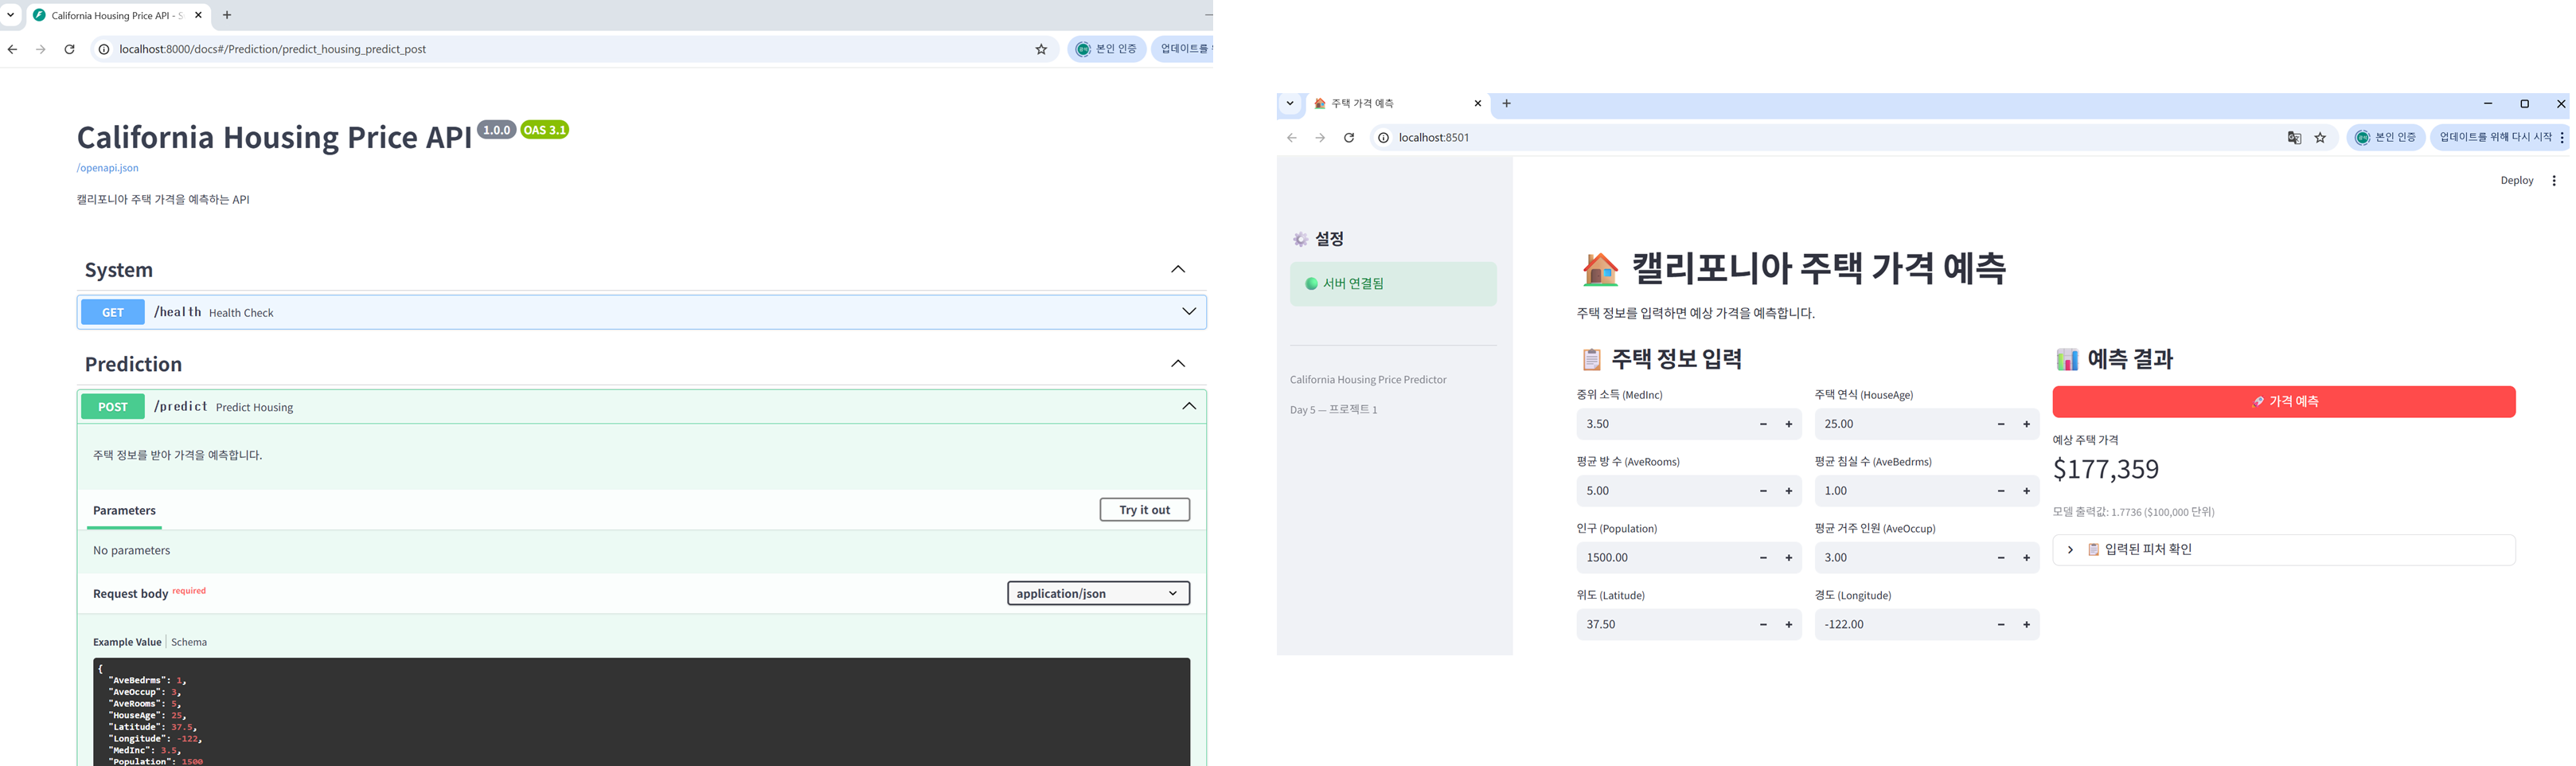

#### 테스트 시나리오

```
위 셀의 iframe에서 바로 조작합니다. (로컬 실행이라면 http://localhost:8501 도 됩니다)

[테스트 1] 기본 흐름
  1. 사이드바 서버 상태 🟢 확인
  2. 기본값 그대로 "🚀 가격 예측" 클릭
  3. 예상 가격이 표시되는지 확인

[테스트 2] 값 변경
  1. 중위 소득을 8.0으로 올리기 → 가격 예측 → 가격 상승 확인
  2. 중위 소득을 1.0으로 내리기 → 가격 예측 → 가격 하락 확인

[테스트 3] 에러 상황
  1. 백엔드 서버를 종료 — 노트북 새 셀에서 stop_server(8000) 실행
  2. 사이드바 상태가 🔴으로 변하는지 확인
  3. 다시 살리려면 serve_in_thread("app.housing_api:app", port=8000)
```


In [10]:
stop_server(8000)  # FastAPI 서버 종료

In [11]:
serve_in_thread("app.housing_api_2:app", port=8000)  # FastAPI 서버 재시작

2026-08-19 15:20:11 INFO     [housing_api_2] LightGBM 모델 로드 중...


2026-08-19 15:20:11 INFO     [housing_api_2] LightGBM 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


## 5. 통합 테스트 및 디버깅

---

> **학습 목표**
> - 전체 서비스(모델 → API → UI)가 정상 동작하는지 체계적으로 테스트합니다.
> - 다양한 입력으로 모델의 동작을 확인합니다.
> - 에러 상황에서 서버가 안정적으로 동작하는지 검증합니다.

---

### 5.1 API 레벨 통합 테스트

In [12]:
# ⚠️ FastAPI 서버가 실행 중이어야 합니다.

import requests
import json
import time

API_BASE = "http://localhost:8000"

test_results = {}   # 각 테스트가 실제 결과를 여기에 기록합니다 — 마지막 종합에서 사용

print("=" * 60)
print("  통합 테스트")
print("=" * 60)


  통합 테스트


#### 테스트 1: 정상 요청

In [13]:
# 다양한 입력으로 모델 동작 확인
test_cases = [
    {"name": "저소득 지역", "MedInc": 1.5, "HouseAge": 40, "AveRooms": 4.0, "AveBedrms": 1.0,
     "Population": 2000, "AveOccup": 3.5, "Latitude": 34.0, "Longitude": -118.0},
    {"name": "고소득 지역", "MedInc": 10.0, "HouseAge": 10, "AveRooms": 8.0, "AveBedrms": 2.0,
     "Population": 500, "AveOccup": 2.0, "Latitude": 37.8, "Longitude": -122.4},
    {"name": "평균적 주택", "MedInc": 3.5, "HouseAge": 25, "AveRooms": 5.0, "AveBedrms": 1.0,
     "Population": 1500, "AveOccup": 3.0, "Latitude": 37.5, "Longitude": -122.0},
]

print("\n[테스트 1] 정상 요청 — 다양한 입력")
print(f"{'케이스':<15} {'예측 가격':>12}")
print("-" * 30)

statuses = []
for case in test_cases:
    name = case.pop("name")
    resp = requests.post(f"{API_BASE}/predict", json=case)    # *your code* — POST 요청
    statuses.append(resp.status_code)
    if resp.status_code == 200:
        print(f"{name:<15} ${resp.json()['predicted_price_usd']:>10,}")
    else:
        print(f"{name:<15} ❌ HTTP {resp.status_code}")
    case["name"] = name  # 복원

test_results["정상 요청"] = all(s == 200 for s in statuses)   # 세 케이스 모두 200이어야 통과



[테스트 1] 정상 요청 — 다양한 입력
케이스                    예측 가격
------------------------------
저소득 지역          $   121,421
고소득 지역          $   465,610
평균적 주택          $   212,027


#### 테스트 2: 에러 상황

In [14]:
print("\n[테스트 2] 에러 상황")
error_statuses = []

# 필수 필드 누락
resp = requests.post(f"{API_BASE}/predict", json={"MedInc": 3.5})
error_statuses.append(resp.status_code)
print(f"  필드 누락      → HTTP {resp.status_code}")

# 범위 초과 (위도)
bad_request = {
    "MedInc": 3.5, "HouseAge": 25, "AveRooms": 5, "AveBedrms": 1,
    "Population": 1500, "AveOccup": 3, "Latitude": 50.0, "Longitude": -122.0,  # 위도 초과
}
resp = requests.post(f"{API_BASE}/predict", json=bad_request)
error_statuses.append(resp.status_code)
print(f"  위도 범위 초과  → HTTP {resp.status_code}")

# 음수 값
bad_request2 = {
    "MedInc": -1.0, "HouseAge": 25, "AveRooms": 5, "AveBedrms": 1,
    "Population": 1500, "AveOccup": 3, "Latitude": 37.5, "Longitude": -122.0,
}
resp = requests.post(f"{API_BASE}/predict", json=bad_request2)
error_statuses.append(resp.status_code)
print(f"  소득 음수      → HTTP {resp.status_code}")

# JSON이 아닌 요청
resp = requests.post(f"{API_BASE}/predict", data="not json")
error_statuses.append(resp.status_code)
print(f"  잘못된 포맷    → HTTP {resp.status_code}")

# 모두 4xx(클라이언트 잘못)로 거부되어야 통과 — 200(통과시킴)이나 500(서버 죽음)이면 실패
test_results["에러 처리"] = all(400 <= s < 500 for s in error_statuses)


POST /predict → 422 (0.002s)
POST /predict → 422 (0.001s)
POST /predict → 422 (0.001s)
POST /predict → 422 (0.001s)



[테스트 2] 에러 상황
  필드 누락      → HTTP 422
  위도 범위 초과  → HTTP 422
  소득 음수      → HTTP 422
  잘못된 포맷    → HTTP 422


#### 테스트 3: 동시 요청

In [15]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def send_predict(i):
    case = test_cases[i % len(test_cases)].copy()
    case.pop("name", None)
    start = time.time()
    resp = requests.post(f"{API_BASE}/predict", json=case, timeout=30)
    return {"id": i+1, "elapsed": round(time.time() - start, 3), "status": resp.status_code}

print("\n[테스트 3] 동시 요청 (8개)")
start = time.time()
with ThreadPoolExecutor(max_workers=8) as ex:
    futures = [ex.submit(send_predict, i) for i in range(8)]
    results = [f.result() for f in as_completed(futures)]

total = round(time.time() - start, 2)
for r in sorted(results, key=lambda x: x["id"]):
    print(f"  요청 #{r['id']}: {r['elapsed']}초 (HTTP {r['status']})")
print(f"  전체: {total}초")

test_results["동시 처리"] = all(r["status"] == 200 for r in results)   # 8건 모두 200이어야 통과



[테스트 3] 동시 요청 (8개)
  요청 #1: 0.043초 (HTTP 200)
  요청 #2: 0.04초 (HTTP 200)
  요청 #3: 0.032초 (HTTP 200)
  요청 #4: 0.033초 (HTTP 200)
  요청 #5: 0.031초 (HTTP 200)
  요청 #6: 0.031초 (HTTP 200)
  요청 #7: 0.029초 (HTTP 200)
  요청 #8: 0.03초 (HTTP 200)
  전체: 0.04초


#### 테스트 4: 헬스체크

In [16]:
print("\n[테스트 4] 헬스체크")
resp = requests.get(f"{API_BASE}/health")
print(f"  상태: {resp.json()}")

test_results["헬스체크"] = resp.status_code == 200 and resp.json().get("status") == "healthy"



[테스트 4] 헬스체크
  상태: {'status': 'healthy', 'model': 'California Housing (LightGBM)'}


---

### 5.2 테스트 결과 종합

In [17]:
print("\n" + "=" * 60)
print("  테스트 결과 종합")
print("=" * 60)

# 위 테스트 셀들이 test_results에 기록한 '실제 결과'로 판정합니다.
DESCRIPTIONS = {
    "정상 요청": "다양한 입력에서 200과 예측 가격 반환",
    "에러 처리": "잘못된 입력을 4xx로 거부, 서버 안 죽음",
    "동시 처리": "8개 동시 요청 모두 200",
    "헬스체크": "서버 상태 healthy",
}

for key, desc in DESCRIPTIONS.items():
    if key not in test_results:
        print(f"  ⚠️ {key}: 아직 실행되지 않음 — 위 테스트 셀을 먼저 실행하세요")
    elif test_results[key]:
        print(f"  ✅ {key}: {desc}")
    else:
        print(f"  ❌ {key}: 실패 — 위 테스트 셀의 출력을 확인하세요")

if all(test_results.get(k) for k in DESCRIPTIONS):
    print("\n🎉 4가지 테스트를 모두 통과했습니다. 회고를 작성하고 제출하세요!")
else:
    print("\n⚠️ 통과하지 못한 테스트가 있습니다. 서버 상태와 위 셀들의 출력을 확인하세요.")



  테스트 결과 종합
  ✅ 정상 요청: 다양한 입력에서 200과 예측 가격 반환
  ✅ 에러 처리: 잘못된 입력을 4xx로 거부, 서버 안 죽음
  ✅ 동시 처리: 8개 동시 요청 모두 200
  ✅ 헬스체크: 서버 상태 healthy

🎉 4가지 테스트를 모두 통과했습니다. 회고를 작성하고 제출하세요!


---

## 6. 회고: 무엇이 어려웠고, 어떻게 개선할 수 있는가?

---


---


### 1. 프로젝트 파일 구성 및 역할

| 단계 | 파일 경로 | 역할 | 사용한 기술 |
| :--- | :--- | :--- | :--- |
| **Data & Model** | `day5_project1.ipynb` | 데이터 탐색(EDA), 전처리(이상치 제거, 로그 변환), PyTorch 및 LightGBM 모델 학습, 성능 평가 | Pandas, Matplotlib, PyTorch, LightGBM, Scikit-Learn |
| **API Schema** | `app/housing_schemas_2.py` | API 요청/응답 데이터 규격 정의 및 프론트엔드 제약 사항(범위)을 기반으로 한 유효성 검사 | Pydantic (`Field`, `ge`, `le`) |
| **Inference Module** | `app/housing_model_3.py` | 학습된 LightGBM 모델과 전처리 파라미터를 로드하여 추론 과정을 캡슐화 | Numpy, Joblib |
| **API Server** | `app/housing_api_2.py` | 클라이언트의 요청을 받아 비동기 스레드풀에서 모델 추론을 수행하고 결과를 반환하는 웹 서버 | FastAPI, Uvicorn, Asyncio, ThreadPoolExecutor |

### 2. 데이터셋 EDA 및 정제 (Data Cleaning)
- **EDA 수행**: 히스토그램과 상자 수염 그림(Boxplot)을 통해 `AveRooms`, `AveBedrms`, `Population`, `AveOccup` 피처들이 심하게 오른쪽으로 치우친(Skewed) 형태임을 확인했습니다.
- **이상치(Outlier) 제거**: 프론트엔드 UI의 입력 허용 범위(예: 방 개수 0.1~50개)를 벗어나는 비현실적인 특이값(방 141개 등)들을 제거하여, 모델이 우리 서비스 타겟에 완전히 집중할 수 있도록 정제했습니다.
- **로그 변환(Log Transform)**: 치우침이 심한 4개의 피처에 `np.log1p`를 적용하여 데이터의 분포를 정규 분포에 가깝게 만들고 학습 안정성을 높였습니다.

### 3. 기존 PyTorch MLP ➔ LightGBM 모델 전환을 통한 개선점
- **오차(MAE)의 획기적 감소**: 깊은 층과 스케줄러까지 동원했던 PyTorch MLP(약 `$36,299`)에 비해 LightGBM(약 `$28,593`)이 오차를 22% 이상 줄이며, 정형 데이터에서의 트리 앙상블 모델의 우수성을 입증했습니다.
- **특이 케이스 방어력 (Robustness)**: 소득 수준이 1.6으로 극단적으로 낮은 LA 남부 특정 지역 데이터에서, MLP는 딥러닝 연산 특유의 Extrapolation 한계로 `$4,764`라는 터무니없는 값을 예측했습니다. 반면 LightGBM은 `$97,296` (실제값 `$90,900`)으로 실제 가격에 거의 근접하게 방어해 내는 안정성을 보여주었습니다.
- **코드 및 구조의 경량화**: 텐서(Tensor) 변환, 신경망 클래스(`nn.Module`) 정의, Dataloader 및 학습 반복문이 모두 사라지고 `.fit()` 한 줄로 대체되어 코드 가독성이 극적으로 향상되었습니다. 추론(서빙) 측면에서도 코드가 절반 이하로 줄어들어 유지보수가 훨씬 용이해졌습니다.

---

### 📌 Day 5 요약

```
오늘 한 일:
  ✅ 캘리포니아 주택 가격 데이터를 탐색하고 전처리 파이프라인을 구성했습니다.
  ✅ PyTorch 회귀 모델을 학습하고 전처리 파라미터와 함께 저장했습니다.
  ✅ FastAPI로 추론 API를 구축했습니다 (Pydantic 검증 + 비동기 처리).
  ✅ Streamlit으로 입력 폼 대시보드를 만들고 API와 연결했습니다.
  ✅ 통합 테스트로 정상/에러/동시 요청을 검증했습니다.
  ✅ Day 1~4의 모든 기술을 하나의 서비스에 통합하는 경험을 했습니다.

내일 할 일 (Day 6):
  🔜 API Key 인증을 적용하여 허용된 사용자만 호출하도록 합니다.
  🔜 이미지, 텍스트 등 비정형 데이터를 처리하는 방법을 배웁니다.
  🔜 파일 업로드와 안전장치(크기 제한, 리사이징)를 구현합니다.
```

---

### 📄 Document Information

- **작성자**: 이다겸
- **최종 작성일**: 2026년 8월 19일
- **프로젝트명**: 주택 가격 예측 모델 파이프라인 구축 및 API 서빙 (Day 5)
- **작업 환경 및 기술 스택**: 
  - **OS**: macOS
  - **Language**: Python 3.11
  - **ML/DL**: PyTorch, LightGBM, Scikit-Learn
  - **Serving**: FastAPI, Uvicorn, Pydantic
- **데이터셋**: California Housing Dataset (Scikit-Learn 내장 데이터)
- **리뷰어에게 남기는 말**: 
  > 데이터 탐색(EDA) 결과를 바탕으로 프론트엔드 환경을 고려한 이상치 제거 로직을 구현했습니다. 특히, 정형 데이터에서 딥러닝(MLP)이 가지는 한계점을 분석하고, 이를 보완하기 위해 트리 앙상블 모델(LightGBM)로 전환하여 오차를 22% 이상 줄인 부분(Section 2.6)을 중점적으로 리뷰해 주시면 감사하겠습니다.